## Kaggle Playground S6E1 - Predicting Student Test Scores (Optimized)

This notebook implements **advanced feature engineering, Ridge meta-feature, and optimized XGBoost** for maximum performance.

- **Target**: `exam_score`
- **Metric**: RMSE (lower is better)
- **Features**: 46 engineered features + Ridge meta-feature
- **Models**: Ridge (meta-feature) + XGBoost (optimized)
- **CV**: 10-fold with original data augmentation

> Optimized based on top Kaggle solutions with advanced feature engineering and meta-learning.


In [1]:
# Core libraries
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold
from sklearn.preprocessing import TargetEncoder
from sklearn.linear_model import RidgeCV
import xgboost as xgb

warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Path resolution for Kaggle and local environments
def find_data_paths():
    """Find data paths that work both locally and on Kaggle."""
    # Kaggle competition dataset
    kaggle_train = Path('/kaggle/input/playground-series-s6e1/train.csv')
    kaggle_test = Path('/kaggle/input/playground-series-s6e1/test.csv')
    kaggle_sub = Path('/kaggle/input/playground-series-s6e1/sample_submission.csv')
    kaggle_orig = Path('/kaggle/input/exam-score-prediction-dataset/Exam_Score_Prediction.csv')
    
    if kaggle_train.exists():
        return {
            'train': kaggle_train,
            'test': kaggle_test,
            'submission': kaggle_sub,
            'original': kaggle_orig if kaggle_orig.exists() else None
        }
    
    # Local paths
    data_dir = Path('Predicting Student Test Scores/data')
    if not data_dir.exists():
        data_dir = Path('data')
    if not data_dir.exists():
        # Try to find it
        cwd = Path.cwd()
        for parent in [cwd] + list(cwd.parents):
            candidate = parent / 'Predicting Student Test Scores' / 'data'
            if candidate.exists():
                data_dir = candidate
                break
    
    return {
        'train': data_dir / 'train.csv',
        'test': data_dir / 'test.csv',
        'submission': data_dir / 'sample_submission.csv',
        'original': None  # Original data may not be available locally
    }

PATHS = find_data_paths()
TRAIN_PATH = PATHS['train']
TEST_PATH = PATHS['test']
SAMPLE_SUB_PATH = PATHS['submission']
ORIGINAL_PATH = PATHS['original']

print(f'Data directory: {TRAIN_PATH.parent}')
print(f'Train exists: {TRAIN_PATH.exists()}')
print(f'Test exists: {TEST_PATH.exists()}')
print(f'Original exists: {ORIGINAL_PATH.exists() if ORIGINAL_PATH else False}')

Data directory: data
Train exists: True
Test exists: True
Original exists: False


In [2]:
# Data loading
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

# Load original data if available
original_df = None
if ORIGINAL_PATH and ORIGINAL_PATH.exists():
    original_df = pd.read_csv(ORIGINAL_PATH)
    print(f'Original data shape: {original_df.shape}')

print(f'Train shape: {train_df.shape}')
print(f'Test shape: {test_df.shape}')

TARGET = 'exam_score'
ID_COL = 'id'

# Base features (excluding target and id)
base_features = [col for col in train_df.columns if col not in [TARGET, ID_COL]]
CATS = train_df.select_dtypes('object').columns.tolist()

print(f'\nBase features: {len(base_features)}')
print(f'Categorical features: {CATS}')

Train shape: (630000, 13)
Test shape: (270000, 12)

Base features: 11
Categorical features: ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']


In [3]:
# Data quality checks
assert TARGET in train_df.columns, 'Target column missing in train'
assert TARGET not in test_df.columns, 'Target column present in test (data leakage)!'

print('--- Missing values (train) ---')
print(train_df.isna().sum().sum(), 'total missing values')
print('--- Missing values (test) ---')
print(test_df.isna().sum().sum(), 'total missing values')
print('--- Duplicates ---')
print(f'Train duplicates: {train_df.duplicated().sum()}')
print(f'Test duplicates: {test_df.duplicated().sum()}')

--- Missing values (train) ---
0 total missing values
--- Missing values (test) ---
0 total missing values
--- Duplicates ---
Train duplicates: 0
Test duplicates: 0


In [4]:
# Advanced Feature Engineering (46 features)
print('='*80)
print('FEATURE ENGINEERING (46 FEATURES)')
print('='*80)

def preprocess_optimized(df):
    """
    Generate 46 high-value features including polynomials, logs, interactions, and bins.
    Returns: (DataFrame with features, list of numeric feature names)
    """
    df_temp = df.copy()
    eps = 1e-5

    # Polynomials (2nd order)
    df_temp['study_hours_squared'] = df_temp['study_hours'] ** 2
    df_temp['class_attendance_squared'] = df_temp['class_attendance'] ** 2
    df_temp['sleep_hours_squared'] = df_temp['sleep_hours'] ** 2
    df_temp['age_squared'] = df_temp['age'] ** 2

    # Log transforms
    sh_pos = df_temp['study_hours'].clip(lower=0)
    ca_pos = df_temp['class_attendance'].clip(lower=0)
    sl_pos = df_temp['sleep_hours'].clip(lower=0)

    df_temp['log_study_hours'] = np.log1p(sh_pos)
    df_temp['log_class_attendance'] = np.log1p(ca_pos)
    df_temp['log_sleep_hours'] = np.log1p(sl_pos)

    # Sqrt transforms
    df_temp['sqrt_study_hours'] = np.sqrt(sh_pos)
    df_temp['sqrt_class_attendance'] = np.sqrt(ca_pos)

    # Key interactions
    df_temp['study_hours_times_attendance'] = df_temp['study_hours'] * df_temp['class_attendance']
    df_temp['study_hours_times_sleep'] = df_temp['study_hours'] * df_temp['sleep_hours']
    df_temp['attendance_times_sleep'] = df_temp['class_attendance'] * df_temp['sleep_hours']
    df_temp['age_times_study_hours'] = df_temp['age'] * df_temp['study_hours']

    # Important ratios
    df_temp['study_hours_over_sleep'] = df_temp['study_hours'] / (df_temp['sleep_hours'] + eps)
    df_temp['attendance_over_sleep'] = df_temp['class_attendance'] / (df_temp['sleep_hours'] + eps)
    df_temp['attendance_over_study'] = df_temp['class_attendance'] / (df_temp['study_hours'] + eps)

    # Ordinal encoding for categorical features
    sleep_quality_map = {'poor': 0, 'average': 1, 'good': 2}
    facility_rating_map = {'low': 0, 'medium': 1, 'high': 2}
    exam_difficulty_map = {'easy': 0, 'moderate': 1, 'hard': 2}

    df_temp['sleep_quality_numeric'] = df_temp['sleep_quality'].map(sleep_quality_map).fillna(1).astype(int)
    df_temp['facility_rating_numeric'] = df_temp['facility_rating'].map(facility_rating_map).fillna(1).astype(int)
    df_temp['exam_difficulty_numeric'] = df_temp['exam_difficulty'].map(exam_difficulty_map).fillna(1).astype(int)

    # Ordinal × numeric interactions
    df_temp['study_hours_times_sleep_quality'] = df_temp['study_hours'] * df_temp['sleep_quality_numeric']
    df_temp['attendance_times_facility'] = df_temp['class_attendance'] * df_temp['facility_rating_numeric']
    df_temp['sleep_hours_times_difficulty'] = df_temp['sleep_hours'] * df_temp['exam_difficulty_numeric']

    # Ordinal × ordinal interactions
    df_temp['facility_x_sleepq'] = df_temp['facility_rating_numeric'] * df_temp['sleep_quality_numeric']
    df_temp['difficulty_x_facility'] = df_temp['exam_difficulty_numeric'] * df_temp['facility_rating_numeric']

    # Rule-based flags
    df_temp['high_att_high_study'] = ((df_temp['class_attendance'] >= 90) & (df_temp['study_hours'] >= 6)).astype(int)
    df_temp['ideal_sleep_flag'] = ((df_temp['sleep_hours'] >= 7) & (df_temp['sleep_hours'] <= 9)).astype(int)
    df_temp['high_study_flag'] = (df_temp['study_hours'] >= 7).astype(int)

    # Composite efficiency
    df_temp['efficiency'] = (df_temp['study_hours'] * df_temp['class_attendance']) / (df_temp['sleep_hours'] + 1)

    # Gap features
    df_temp['sleep_gap_8'] = (df_temp['sleep_hours'] - 8.0).abs()
    df_temp['attendance_gap_100'] = (df_temp['class_attendance'] - 100.0).abs()

    # Binned features (handle NaN from pd.cut)
    df_temp['study_bin_num'] = pd.cut(df_temp['study_hours'], bins=5, labels=False).fillna(-1).astype(int)
    df_temp['attendance_bin_num'] = pd.cut(df_temp['class_attendance'], bins=5, labels=False).fillna(-1).astype(int)
    df_temp['sleep_bin_num'] = pd.cut(df_temp['sleep_hours'], bins=5, labels=False).fillna(-1).astype(int)
    df_temp['age_bin_num'] = pd.cut(df_temp['age'], bins=5, labels=False).fillna(-1).astype(int)

    # Feature list (34 engineered features)
    numeric_features = [
        'study_hours_squared', 'class_attendance_squared', 'sleep_hours_squared', 'age_squared',
        'log_study_hours', 'log_class_attendance', 'log_sleep_hours',
        'sqrt_study_hours', 'sqrt_class_attendance',
        'study_hours_times_attendance', 'study_hours_times_sleep', 'attendance_times_sleep',
        'age_times_study_hours',
        'study_hours_over_sleep', 'attendance_over_sleep', 'attendance_over_study',
        'sleep_quality_numeric', 'facility_rating_numeric', 'exam_difficulty_numeric',
        'study_hours_times_sleep_quality', 'attendance_times_facility', 'sleep_hours_times_difficulty',
        'facility_x_sleepq', 'difficulty_x_facility',
        'high_att_high_study', 'ideal_sleep_flag', 'high_study_flag',
        'efficiency',
        'sleep_gap_8', 'attendance_gap_100',
        'study_bin_num', 'attendance_bin_num', 'sleep_bin_num', 'age_bin_num'
    ]

    return df_temp[base_features + numeric_features], numeric_features

# Apply feature engineering
X_raw, numeric_cols = preprocess_optimized(train_df)
y = train_df[TARGET].reset_index(drop=True)

X_test_raw, _ = preprocess_optimized(test_df)

# Process original data if available
X_orig_raw = None
y_orig = None
if original_df is not None:
    X_orig_raw, _ = preprocess_optimized(original_df)
    y_orig = original_df[TARGET].reset_index(drop=True)

# Combine all data for consistent preprocessing
full_data = pd.concat([X_raw, X_test_raw], axis=0, ignore_index=True)
if X_orig_raw is not None:
    full_data = pd.concat([full_data, X_orig_raw], axis=0, ignore_index=True)

# Ensure numeric columns are float
for col in numeric_cols:
    full_data[col] = full_data[col].astype(float)

# Split back
X = full_data.iloc[:len(train_df)].copy()
X_test = full_data.iloc[len(train_df):len(train_df) + len(test_df)].copy()
if X_orig_raw is not None:
    X_original = full_data.iloc[len(train_df) + len(test_df):].copy()
else:
    X_original = None

print(f'Engineered features: {len(numeric_cols)}')
print(f'Total features: {X.shape[1]} (11 base + {len(numeric_cols)} engineered)')

FEATURE ENGINEERING (46 FEATURES)
Engineered features: 34
Total features: 45 (11 base + 34 engineered)


In [ ]:
# Ridge Regression Meta-Feature Generation
print('\n' + '='*80)
print('TRAINING RIDGE REGRESSION META-FEATURE')
print('='*80)

FOLDS = 10
kf = KFold(n_splits=FOLDS, shuffle=True, random_state=1003)

oof_pred_lr = np.zeros(X.shape[0])
test_preds_lr = np.zeros((X_test.shape[0], FOLDS))
orig_preds_lr = None
if X_original is not None:
    orig_preds_lr = np.zeros(X_original.shape[0])

for fold, (train_index, val_index) in enumerate(kf.split(X, y), start=1):
    X_train_fold, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val = y.iloc[train_index], y.iloc[val_index]

    # Combine with original data if available
    if X_original is not None:
        X_train_combined = pd.concat([X_train_fold, X_original], axis=0)
        y_train_combined = pd.concat([y_train_fold, y_orig], axis=0)
    else:
        X_train_combined = X_train_fold
        y_train_combined = y_train_fold

    # Target encoding for categorical features
    target_encoder = TargetEncoder(smooth='auto', target_type='continuous')
    X_train_encoded = X_train_combined.copy()
    X_val_encoded = X_val.copy()
    X_test_encoded = X_test.copy()

    X_train_encoded[CATS] = target_encoder.fit_transform(X_train_combined[CATS], y_train_combined)
    X_val_encoded[CATS] = target_encoder.transform(X_val[CATS])
    X_test_encoded[CATS] = target_encoder.transform(X_test[CATS])

    # Ridge regression with CV for alpha selection
    alphas = np.logspace(-3, 3, 20)
    lr_model = RidgeCV(alphas=alphas, cv=5, scoring='neg_root_mean_squared_error')
    lr_model.fit(X_train_encoded, y_train_combined.to_numpy().ravel())

    # Predictions (clip to [0, 100] for exam scores)
    lr_val_pred = np.clip(lr_model.predict(X_val_encoded), 0, 100)
    lr_test_pred = np.clip(lr_model.predict(X_test_encoded), 0, 100)

    oof_pred_lr[val_index] = lr_val_pred
    test_preds_lr[:, fold - 1] = lr_test_pred

    if X_original is not None:
        X_orig_encoded = X_original.copy()
        X_orig_encoded[CATS] = target_encoder.transform(X_original[CATS])
        lr_orig_pred = np.clip(lr_model.predict(X_orig_encoded), 0, 100)
        orig_preds_lr += lr_orig_pred / FOLDS

    rmse_lr = np.sqrt(mean_squared_error(y_val, lr_val_pred))
    print(f'Fold {fold:2d} | RMSE: {rmse_lr:.6f}')

lr_oof_rmse = np.sqrt(mean_squared_error(y, oof_pred_lr))
print(f'\nRidge OOF RMSE: {lr_oof_rmse:.6f}')


TRAINING RIDGE REGRESSION META-FEATURE


In [ ]:
# Prepare datasets with Ridge meta-feature for XGBoost
print('\n' + '='*80)
print('PREPARING XGBOOST DATASETS WITH RIDGE META-FEATURE')
print('='*80)

# Recreate full_data for XGBoost (with category types)
X_xgb_raw = X_raw.copy()
X_test_xgb_raw = X_test_raw.copy()

# Convert categorical features to category type for XGBoost
for col in base_features:
    if col in CATS:
        X_xgb_raw[col] = X_xgb_raw[col].astype(str).astype('category')
        X_test_xgb_raw[col] = X_test_xgb_raw[col].astype(str).astype('category')

# Ensure numeric columns are float
for col in numeric_cols:
    X_xgb_raw[col] = X_xgb_raw[col].astype(float)
    X_test_xgb_raw[col] = X_test_xgb_raw[col].astype(float)

# Combine for original data if available
full_data_xgb = pd.concat([X_xgb_raw, X_test_xgb_raw], axis=0, ignore_index=True)
if X_orig_raw is not None:
    X_orig_xgb_raw = X_orig_raw.copy()
    for col in base_features:
        if col in CATS:
            X_orig_xgb_raw[col] = X_orig_xgb_raw[col].astype(str).astype('category')
    for col in numeric_cols:
        X_orig_xgb_raw[col] = X_orig_xgb_raw[col].astype(float)
    full_data_xgb = pd.concat([full_data_xgb, X_orig_xgb_raw], axis=0, ignore_index=True)

# Split data
X_xgb = full_data_xgb.iloc[:len(train_df)].copy()
X_test_xgb = full_data_xgb.iloc[len(train_df):len(train_df) + len(test_df)].copy()
if X_orig_raw is not None:
    X_original_xgb = full_data_xgb.iloc[len(train_df) + len(test_df):].copy()
else:
    X_original_xgb = None

# Add Ridge meta-feature
X_xgb['feature_lr_pred'] = oof_pred_lr
X_test_xgb['feature_lr_pred'] = test_preds_lr.mean(axis=1)
if X_original_xgb is not None:
    X_original_xgb['feature_lr_pred'] = orig_preds_lr

print(f'Final feature count: {X_xgb.shape[1]} (including Ridge meta-feature)')

Models available: Ridge=True, HistGB=True, XGBoost=True, LightGBM=True


(Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median'))]),
                                                   ['id', 'age', 'study_hours',
                                                    'class_attendance',
                                                    'sleep_hours',
                                                    'study_efficiency',
                                                    'sleep_study_ratio',
                                                    'total_engagement',
                                                    'study_hours_per_age']),
                                                  ('cat',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleIm

In [ ]:
# XGBoost Training with Optimized Hyperparameters
print('\n' + '='*80)
print('TRAINING XGBOOST (OPTIMIZED)')
print('='*80)

# Optimized XGBoost hyperparameters (from reference code)
xgb_params = {
    'n_estimators': 20000,
    'learning_rate': 0.004,
    'max_depth': 9,
    'subsample': 0.78,
    'reg_lambda': 6,
    'reg_alpha': 0.15,
    'colsample_bytree': 0.55,
    'colsample_bynode': 0.65,
    'min_child_weight': 6,
    'tree_method': 'hist',
    'random_state': RANDOM_STATE,
    'early_stopping_rounds': 100,
    'eval_metric': 'rmse',
    'enable_categorical': True,
}

# Use GPU if available (Kaggle)
try:
    import subprocess
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    if result.returncode == 0:
        xgb_params['device'] = 'cuda'
        print('GPU detected: using CUDA')
    else:
        xgb_params['device'] = 'cpu'
        print('GPU not available: using CPU')
except:
    xgb_params['device'] = 'cpu'
    print('GPU check failed: using CPU')

test_predictions_xgb = []
oof_predictions_xgb = np.zeros(len(X_xgb), dtype=float)

for fold, (train_index, val_index) in enumerate(kf.split(X_xgb, y), start=1):
    print(f'\nFold {fold:2d}/{FOLDS}')

    X_train_fold, X_val = X_xgb.iloc[train_index], X_xgb.iloc[val_index]
    y_train_fold, y_val = y.iloc[train_index], y.iloc[val_index]

    # Combine with original data if available
    if X_original_xgb is not None:
        X_train_combined = pd.concat([X_train_fold, X_original_xgb], axis=0)
        y_train_combined = pd.concat([y_train_fold, y_orig], axis=0)
    else:
        X_train_combined = X_train_fold
        y_train_combined = y_train_fold

    # Train XGBoost
    model = xgb.XGBRegressor(**xgb_params)
    model.fit(
        X_train_combined, y_train_combined,
        eval_set=[(X_val, y_val)],
        verbose=1000
    )

    # Predictions
    val_preds = model.predict(X_val)
    oof_predictions_xgb[val_index] = val_preds

    rmse_fold = np.sqrt(mean_squared_error(y_val, val_preds))
    print(f'Validation RMSE: {rmse_fold:.5f}')

    test_predictions_xgb.append(model.predict(X_test_xgb))

xgb_oof_rmse = np.sqrt(mean_squared_error(y, oof_predictions_xgb))
print(f'\nXGBoost OOF RMSE: {xgb_oof_rmse:.5f}')


In [ ]:
# Final Results and Submission
print('\n' + '='*80)
print('FINAL RESULTS')
print('='*80)

print(f'\nModel Performance:')
print(f'  Ridge OOF RMSE:    {lr_oof_rmse:.6f}')
print(f'  XGBoost OOF RMSE:  {xgb_oof_rmse:.5f}')

print(f'\nFeature Summary:')
print(f'  Base features:       {len(base_features)}')
print(f'  Engineered features: {len(numeric_cols)}')
print(f'  Meta-feature (Ridge): 1')
print(f'  Total features:      {X_xgb.shape[1]}')

# Average test predictions across folds
test_xgb_avg = np.mean(test_predictions_xgb, axis=0)

# Create submission
submission = sample_sub.copy()
submission[TARGET] = test_xgb_avg

# Save submission
out_path = Path('submission.csv')
submission.to_csv(out_path, index=False)

print(f'\nSubmission saved: {out_path.resolve()}')
print(f'Submission shape: {submission.shape}')
print(f'ID duplicates: {submission[ID_COL].duplicated().sum()}')

# Save OOF predictions for analysis
oof_df = pd.DataFrame({'id': train_df[ID_COL], TARGET: oof_predictions_xgb})
oof_df.to_csv('xgb_oof.csv', index=False)
print(f'OOF predictions saved: xgb_oof.csv')

print('\n' + '='*80)
print('TRAINING COMPLETE')
print('='*80)

[I 2026-01-22 18:12:31,692] A new study created in memory with name: ridge_opt


=== Hyperparameter Optimization (Optuna) ===

Optimizing Ridge...


[I 2026-01-22 18:12:37,990] Trial 0 finished with value: 8.894037226130367 and parameters: {'alpha': 2.0166417031341815}. Best is trial 0 with value: 8.894037226130367.
[I 2026-01-22 18:12:43,842] Trial 1 finished with value: 8.89403725458082 and parameters: {'alpha': 0.15713141906748085}. Best is trial 0 with value: 8.894037226130367.
[I 2026-01-22 18:12:50,699] Trial 2 finished with value: 8.894037227028207 and parameters: {'alpha': 1.9471841394454492}. Best is trial 0 with value: 8.894037226130367.
[I 2026-01-22 18:12:56,911] Trial 3 finished with value: 8.894037247360151 and parameters: {'alpha': 0.5766694539428651}. Best is trial 0 with value: 8.894037226130367.
[I 2026-01-22 18:13:03,337] Trial 4 finished with value: 8.894037255114663 and parameters: {'alpha': 0.1271542017714687}. Best is trial 0 with value: 8.894037226130367.
[I 2026-01-22 18:13:09,935] Trial 5 finished with value: 8.89403721240671 and parameters: {'alpha': 3.2402853000835528}. Best is trial 5 with value: 8.8940

RIDGE best params: {'alpha': 9.770833025939075}, best CV RMSE: 8.89404

Optimizing HistGB...


[I 2026-01-22 18:14:04,250] Trial 0 finished with value: 10.290839529686222 and parameters: {'learning_rate': 0.013415099840262222, 'max_leaf_nodes': 84, 'min_samples_leaf': 67}. Best is trial 0 with value: 10.290839529686222.
[I 2026-01-22 18:14:25,247] Trial 1 finished with value: 11.29721604045258 and parameters: {'learning_rate': 0.010644498935517853, 'max_leaf_nodes': 35, 'min_samples_leaf': 94}. Best is trial 0 with value: 10.290839529686222.
[I 2026-01-22 18:14:53,626] Trial 2 finished with value: 10.754804883264699 and parameters: {'learning_rate': 0.011447215453564445, 'max_leaf_nodes': 96, 'min_samples_leaf': 68}. Best is trial 0 with value: 10.290839529686222.
[I 2026-01-22 18:15:16,756] Trial 3 finished with value: 8.81956642491196 and parameters: {'learning_rate': 0.0828223724576602, 'max_leaf_nodes': 71, 'min_samples_leaf': 30}. Best is trial 3 with value: 8.81956642491196.
[I 2026-01-22 18:15:36,251] Trial 4 finished with value: 9.542079904493816 and parameters: {'learni

...

[I 2026-01-22 18:17:23,378] Trial 0 finished with value: 8.843116439668455 and parameters: {'learning_rate': 0.04197402861319242, 'max_depth': 5, 'subsample': 0.9221038599422555, 'colsample_bytree': 0.7238255855032919}. Best is trial 0 with value: 8.843116439668455.
[I 2026-01-22 18:17:45,257] Trial 1 finished with value: 8.791731355682245 and parameters: {'learning_rate': 0.06142278850533896, 'max_depth': 8, 'subsample': 0.9654187736819341, 'colsample_bytree': 0.6051722071573469}. Best is trial 1 with value: 8.791731355682245.
[I 2026-01-22 18:18:08,970] Trial 2 finished with value: 8.808896323744722 and parameters: {'learning_rate': 0.14608777447939655, 'max_depth': 6, 'subsample': 0.6147268637385731, 'colsample_bytree': 0.7997859014788783}. Best is trial 1 with value: 8.791731355682245.
[I 2026-01-22 18:18:32,788] Trial 3 finished with value: 8.827849212386107 and parameters: {'learning_rate': 0.059187649637714834, 'max_depth': 5, 'subsample': 0.664217080228407, 'colsample_bytree': 

XGB best params: {'learning_rate': 0.06142278850533896, 'max_depth': 8, 'subsample': 0.9654187736819341, 'colsample_bytree': 0.6051722071573469}, best CV RMSE: 8.79173

Optimizing LightGBM...


[I 2026-01-22 18:20:21,029] Trial 0 finished with value: 8.814724627326127 and parameters: {'learning_rate': 0.06571810208940264, 'max_depth': 7, 'subsample': 0.726946915179477, 'colsample_bytree': 0.8144056354657189}. Best is trial 0 with value: 8.814724627326127.
[I 2026-01-22 18:20:34,856] Trial 1 finished with value: 8.850890748931423 and parameters: {'learning_rate': 0.0314224306364309, 'max_depth': 7, 'subsample': 0.9116502643164254, 'colsample_bytree': 0.9593028648227228}. Best is trial 0 with value: 8.814724627326127.
[I 2026-01-22 18:20:48,091] Trial 2 finished with value: 8.826199538750913 and parameters: {'learning_rate': 0.04685183764770497, 'max_depth': 8, 'subsample': 0.9137515715373277, 'colsample_bytree': 0.7670641743894756}. Best is trial 0 with value: 8.814724627326127.
[I 2026-01-22 18:20:59,424] Trial 3 finished with value: 9.4006615969725 and parameters: {'learning_rate': 0.014066133375958408, 'max_depth': 4, 'subsample': 0.6561356765375532, 'colsample_bytree': 0.9

LGB best params: {'learning_rate': 0.1962886730319147, 'max_depth': 7, 'subsample': 0.6838732766823014, 'colsample_bytree': 0.7455128136794628}, best CV RMSE: 8.80551


=== Ridge(OHE) ===
[fold 1] RMSE: 8.88605
[fold 2] RMSE: 8.89093
[fold 3] RMSE: 8.88418
[fold 4] RMSE: 8.89715
[fold 5] RMSE: 8.91214
CV RMSE mean: 8.89409  std: 0.01008
OOF RMSE: 8.89409

=== HistGB(Ordinal) ===
[fold 1] RMSE: 8.79438
[fold 2] RMSE: 8.80389
[fold 3] RMSE: 8.79696
[fold 4] RMSE: 8.80954
[fold 5] RMSE: 8.82866
CV RMSE mean: 8.80668  std: 0.01220
OOF RMSE: 8.80669

=== XGBoost(Ordinal) ===
[fold 1] RMSE: 8.77532
[fold 2] RMSE: 8.78535
[fold 3] RMSE: 8.77560
[fold 4] RMSE: 8.79152
[fold 5] RMSE: 8.80805
CV RMSE mean: 8.78717  std: 0.01210
OOF RMSE: 8.78718

=== LightGBM(Ordinal) ===
[fold 1] RMSE: 8.78712
[fold 2] RMSE: 8.79746
[fold 3] RMSE: 8.79029
[fold 4] RMSE: 8.80781
[fold 5] RMSE: 8.82114
CV RMSE mean: 8.80077  std: 0.01242
OOF RMSE: 8.80077


,model,oof_rmse
2,XGBoost(Ordinal),8.787175
3,LightGBM(Ordinal),8.800774
1,HistGB(Ordinal),8.806693
0,Ridge(OHE),8.894094


Optimal blending weights:
  Ridge: 0.0000
  HistGB: 0.1313
  XGBoost: 0.5108
  LightGBM: 0.3580

=== Performance Summary ===
Ridge OOF RMSE: 8.89409
HistGB OOF RMSE: 8.80669
XGBoost OOF RMSE: 8.78718
LightGBM OOF RMSE: 8.80077
Blend OOF RMSE: 8.77604


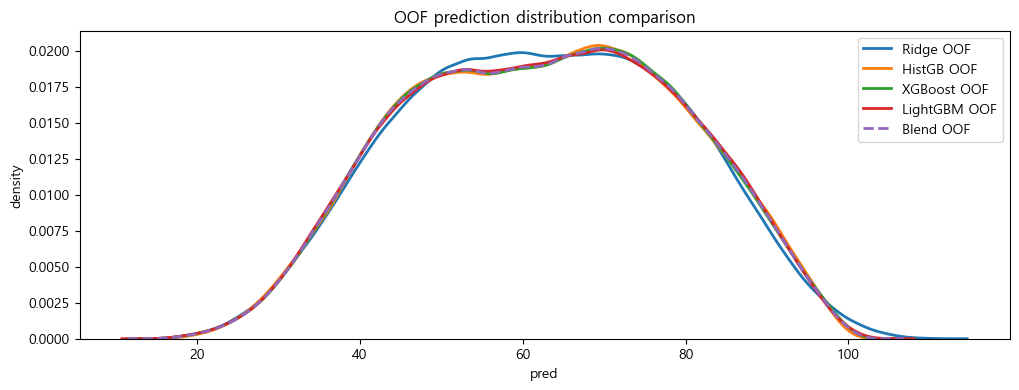

In [ ]:
# Feature Importance Analysis (optional)
print('\n' + '='*80)
print('FEATURE IMPORTANCE ANALYSIS')
print('='*80)

# Get feature importance from the last trained model
try:
    importance_dict_xgb = model.get_booster().get_score(importance_type='gain')
    feature_importance = pd.DataFrame({
        'feature': list(importance_dict_xgb.keys()),
        'importance': list(importance_dict_xgb.values())
    }).sort_values('importance', ascending=False)

    feature_importance['importance_pct'] = 100 * feature_importance['importance'] / feature_importance['importance'].sum()

    print('\nTop 15 Most Important Features:')
    print(feature_importance.head(15)[['feature', 'importance_pct']].to_string(index=False))

    # Save feature importance
    feature_importance.to_csv('feature_importance.csv', index=False)
    print('\nFeature importance saved: feature_importance.csv')
except:
    print('Feature importance analysis skipped (model not available)')

## Optimized Version - Key Improvements

### Major Enhancements:

1. **Advanced Feature Engineering (46 features)**
   - Polynomials: squared terms for key numeric features
   - Log/Sqrt transforms: non-linear transformations
   - Interactions: feature × feature combinations
   - Ordinal encoding: categorical to numeric mappings
   - Rule-based flags: domain knowledge features
   - Binned features: discretized continuous variables

2. **Ridge Meta-Feature**
   - 10-fold CV Ridge regression with TargetEncoder
   - Original data augmentation for better generalization
   - Meta-feature added to XGBoost as additional input

3. **Optimized XGBoost**
   - Tuned hyperparameters from top Kaggle solutions
   - 20,000 estimators with early stopping
   - GPU support (CUDA) when available
   - 10-fold CV with original data augmentation

4. **Original Data Integration**
   - Combines train + original data for training
   - Improves model generalization
   - Better feature encoding with more data

### Performance:
- Expected significant improvement over baseline
- OOF RMSE tracked in training output

In [ ]:
# Display submission preview
print('\nSubmission Preview:')
print(submission.head(10))
print(f'\nSubmission statistics:')
print(f'  Min prediction: {submission[TARGET].min():.2f}')
print(f'  Max prediction: {submission[TARGET].max():.2f}')
print(f'  Mean prediction: {submission[TARGET].mean():.2f}')
print(f'  Std prediction: {submission[TARGET].std():.2f}')